## Deep Compression: Pruning, Quantization, and Huffman Coding

Implements the three-stage deep compression pipeline from [Han et al. (2015)](https://arxiv.org/abs/1510.00149) on a VGG-16 architecture trained on CIFAR-10.

### Pipeline

1. **Pruning**: Remove low-magnitude weights using standard deviation-based thresholding, then fine-tune to recover accuracy.
2. **Quantization (Weight Sharing)**: Apply k-means clustering per layer to reduce the number of unique weight values, storing only centroid indices.
3. **Huffman Coding**: Exploit the non-uniform centroid distribution to further reduce average bit-width via entropy coding.

**Model**: VGG16_half (0.5 width multiplier) | **Dataset**: CIFAR-10 | **Baseline Accuracy**: 90.49%

In [ ]:
from vgg16 import VGG16, VGG16_half
from train_util import train, finetune_after_prune, test
from quantize import quantize_whole_model
from huffman_coding import huffman_coding
from summary import summary
import torch
import numpy as np
from prune import prune

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/content/summary.py:10: SyntaxWarning: invalid escape sequence '\%'
  print("Layer id\tType\t\tParameter\tNon-zero parameter\tSparsity(\%)")


### Full-precision model training

In [ ]:
net = VGG16_half()
net = net.to(device)

# Uncomment to load pretrained weights
net.load_state_dict(torch.load("net_before_pruning.pt"))

# I loaded the pretrained weights since training has already been completed
# train(net, epochs=100, batch_size=128, lr=0.1, reg=1e-4)

<All keys matched successfully>

In [ ]:
# Load the best weight paramters
net.load_state_dict(torch.load("net_before_pruning.pt"))
test(net)

100%|██████████| 170M/170M [00:04<00:00, 35.0MB/s]


Test Loss=0.3227, Test accuracy=0.9049


0.9049

In [ ]:
print("-----Summary before pruning-----")
summary(net)
print("-------------------------------")

-----Summary before pruning-----
Layer id	Type		Parameter	Non-zero parameter	Sparsity(\%)
1		Convolutional	864		864			0.000000
2		BatchNorm	N/A		N/A			N/A
3		ReLU		N/A		N/A			N/A
4		Convolutional	9216		9216			0.000000
5		BatchNorm	N/A		N/A			N/A
6		ReLU		N/A		N/A			N/A
7		Convolutional	18432		18432			0.000000
8		BatchNorm	N/A		N/A			N/A
9		ReLU		N/A		N/A			N/A
10		Convolutional	36864		36864			0.000000
11		BatchNorm	N/A		N/A			N/A
12		ReLU		N/A		N/A			N/A
13		Convolutional	73728		73728			0.000000
14		BatchNorm	N/A		N/A			N/A
15		ReLU		N/A		N/A			N/A
16		Convolutional	147456		147456			0.000000
17		BatchNorm	N/A		N/A			N/A
18		ReLU		N/A		N/A			N/A
19		Convolutional	147456		147456			0.000000
20		BatchNorm	N/A		N/A			N/A
21		ReLU		N/A		N/A			N/A
22		Convolutional	294912		294912			0.000000
23		BatchNorm	N/A		N/A			N/A
24		ReLU		N/A		N/A			N/A
25		Convolutional	589824		589824			0.000000
26		BatchNorm	N/A		N/A			N/A
27		ReLU		N/A		N/A			N/A
28		Convolutional	589824		589824			0.000000
29		Batch

### Pruning & Finetune with pruned connections

#### Pruning Configuration

In [ ]:
# Test accuracy before fine-tuning
prune(net, method='std', q=45.0, s=0.75)
test(net)

Test Loss=1.9888, Test accuracy=0.4861


0.4861

In [ ]:
# Check sparsity per layer
for n, m in net.named_modules():
    if hasattr(m, 'sparsity'):
        print(f"Layer {n} | Sparsity: {m.sparsity:.4f}")

Layer features.0 | Sparsity: 0.7118
Layer features.3 | Sparsity: 0.7039
Layer features.7 | Sparsity: 0.5892
Layer features.10 | Sparsity: 0.5612
Layer features.14 | Sparsity: 0.5551
Layer features.17 | Sparsity: 0.5520
Layer features.20 | Sparsity: 0.5690
Layer features.24 | Sparsity: 0.6232
Layer features.27 | Sparsity: 0.6243
Layer features.30 | Sparsity: 0.6338
Layer features.34 | Sparsity: 0.6430
Layer features.37 | Sparsity: 0.6358
Layer features.40 | Sparsity: 0.6957
Layer classifer.0 | Sparsity: 0.5777
Layer classifer.3 | Sparsity: 0.6565
Layer classifer.6 | Sparsity: 0.6246


In [ ]:
layer_sparsities = [m.sparsity for m in net.modules() if hasattr(m, 'sparsity')]
avg_sparsity = sum(layer_sparsities) / len(layer_sparsities)
print(f"Model Sparsity: {avg_sparsity:.4f}")

Model Sparsity: 0.6223


#### Sensitivity Analysis: Sparsity vs. Accuracy Drop

Test Loss=0.3227, Test accuracy=0.9049
Sensitivity (s)    | Avg Sparsity    | Accuracy Drop (%)
-------------------------------------------------------
Test Loss=0.3227, Test accuracy=0.9049
0.0                | 0.0000          | 0.00           
Test Loss=0.3278, Test accuracy=0.9032
0.25               | 0.2579          | 0.17           
Test Loss=0.4527, Test accuracy=0.8709
0.5                | 0.4618          | 3.40           
Test Loss=1.9888, Test accuracy=0.4861
0.75               | 0.6223          | 41.88          
Test Loss=3.8837, Test accuracy=0.2000
1.0                | 0.7420          | 70.49          
Test Loss=4.8614, Test accuracy=0.1001
1.25               | 0.8258          | 80.48          
Test Loss=4.5355, Test accuracy=0.1000
1.5                | 0.8839          | 80.49          


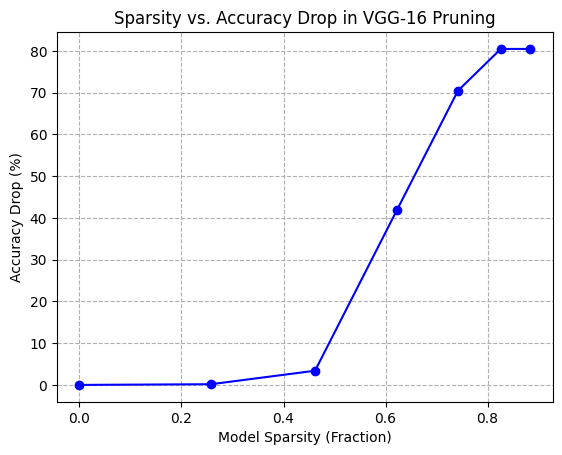

In [ ]:
import matplotlib.pyplot as plt

net.load_state_dict(torch.load('net_before_pruning.pt'))

# Baseline
baseline_acc = test(net)

# Sensitivities to test
s_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
results = []

print(f"{'Sensitivity (s)':<18} | {'Avg Sparsity':<15} | {'Accuracy Drop (%)':<15}")
print("-" * 55)

for s in s_values:
    # Always reset to baseline weights
    net.load_state_dict(torch.load('net_before_pruning.pt'))

    # Apply pruning
    prune(net, method='std', s=s)

    # Capture accuracy
    acc = test(net)

    # Calculate average sparsity across prunable layers
    layer_sparsities = [m.sparsity for m in net.modules() if hasattr(m, 'sparsity')]
    avg_s = sum(layer_sparsities) / len(layer_sparsities)

    # Calculate drop in percentage (e.g., 0.9049 - 0.4861 = 0.4188 -> 41.88%)
    drop = (baseline_acc - acc) * 100
    results.append((avg_s, drop))

    # Print the current threshold and resulting sparsity
    print(f"{s:<18} | {avg_s:<15.4f} | {drop:<15.2f}")

# --- Generate a Better Plot ---
x_sparsity, y_drop = zip(*sorted(results))

plt.plot(x_sparsity, y_drop, marker='o', linestyle='-', color='blue')

plt.title('Sparsity vs. Accuracy Drop in VGG-16 Pruning')
plt.xlabel('Model Sparsity (Fraction)')
plt.ylabel('Accuracy Drop (%)')
plt.grid(True, linestyle='--')

plt.show()

#### Comparison: Std-based vs. Percentage Pruning

In [ ]:
# Reset to baseline
net.load_state_dict(torch.load('net_before_pruning.pt'))

# Apply pruning using percentage to match problem (c) sparsity
prune(net, method='percentage', q=62.23)

# Evaluate
acc_percentage = test(net)
drop_percentage = (baseline_acc - acc_percentage) * 100

print(f"Percentage Method (q=62.23) Accuracy Drop: {drop_percentage:.2f}%")

Test Loss=1.8444, Test accuracy=0.4682
Percentage Method (q=62.23) Accuracy Drop: 43.67%


#### Fine-tuning with Pruned Connections

In [ ]:
# Reset to baseline
net.load_state_dict(torch.load('net_before_pruning.pt'))

# Test accuracy before fine-tuning
prune(net, method='std', q=45.0, s=0.75)
test(net)

Test Loss=1.9888, Test accuracy=0.4861


0.4861

In [ ]:
# Uncomment to load pretrained weights
net.load_state_dict(torch.load("net_after_pruning.pt"))

# I loaded the pretrained weights since fine-tuned training has already been completed

# Comment if you have loaded pretrained weights
# finetune_after_prune(net, epochs=50, batch_size=128, lr=0.001, reg=5e-5)

<All keys matched successfully>

In [ ]:
# Load the best weight paramters
net.load_state_dict(torch.load("net_after_pruning.pt"))
test(net)

Test Loss=0.3392, Test accuracy=0.9033


0.9033

In [ ]:
print("-----Summary After pruning-----")
summary(net)
print("-------------------------------")

-----Summary After pruning-----
Layer id	Type		Parameter	Non-zero parameter	Sparsity(\%)
1		Convolutional	864		249			0.711806
2		BatchNorm	N/A		N/A			N/A
3		ReLU		N/A		N/A			N/A
4		Convolutional	9216		2729			0.703885
5		BatchNorm	N/A		N/A			N/A
6		ReLU		N/A		N/A			N/A
7		Convolutional	18432		7571			0.589247
8		BatchNorm	N/A		N/A			N/A
9		ReLU		N/A		N/A			N/A
10		Convolutional	36864		16176			0.561198
11		BatchNorm	N/A		N/A			N/A
12		ReLU		N/A		N/A			N/A
13		Convolutional	73728		32804			0.555067
14		BatchNorm	N/A		N/A			N/A
15		ReLU		N/A		N/A			N/A
16		Convolutional	147456		66053			0.552049
17		BatchNorm	N/A		N/A			N/A
18		ReLU		N/A		N/A			N/A
19		Convolutional	147456		63555			0.568990
20		BatchNorm	N/A		N/A			N/A
21		ReLU		N/A		N/A			N/A
22		Convolutional	294912		111124			0.623196
23		BatchNorm	N/A		N/A			N/A
24		ReLU		N/A		N/A			N/A
25		Convolutional	589824		221603			0.624290
26		BatchNorm	N/A		N/A			N/A
27		ReLU		N/A		N/A			N/A
28		Convolutional	589824		215984			0.633816
29		BatchNorm

### Quantization

In [ ]:
centers = quantize_whole_model(net, bits=5)
np.save("codebook_vgg16.npy", centers)

Complete 1 layers quantization...
Complete 2 layers quantization...
Complete 3 layers quantization...
Complete 4 layers quantization...
Complete 5 layers quantization...
Complete 6 layers quantization...
Complete 7 layers quantization...
Complete 8 layers quantization...
Complete 9 layers quantization...
Complete 10 layers quantization...
Complete 11 layers quantization...
Complete 12 layers quantization...
Complete 13 layers quantization...
Complete 14 layers quantization...
Complete 15 layers quantization...
Complete 16 layers quantization...


In [ ]:
test(net)

Test Loss=0.3416, Test accuracy=0.9029


0.9029

Test Loss=0.3392, Test accuracy=0.9033
Bits       | Centroids  | Accuracy     | Drop from FT (%)
-------------------------------------------------------
Complete 1 layers quantization...
Complete 2 layers quantization...
Complete 3 layers quantization...
Complete 4 layers quantization...
Complete 5 layers quantization...
Complete 6 layers quantization...
Complete 7 layers quantization...
Complete 8 layers quantization...
Complete 9 layers quantization...
Complete 10 layers quantization...
Complete 11 layers quantization...
Complete 12 layers quantization...
Complete 13 layers quantization...
Complete 14 layers quantization...
Complete 15 layers quantization...
Complete 16 layers quantization...
Test Loss=1.1052, Test accuracy=0.6358
2          | 4          | 0.6358       | 26.75          
Complete 1 layers quantization...
Complete 2 layers quantization...
Complete 3 layers quantization...
Complete 4 layers quantization...
Complete 5 layers quantization...
Complete 6 layers quantization

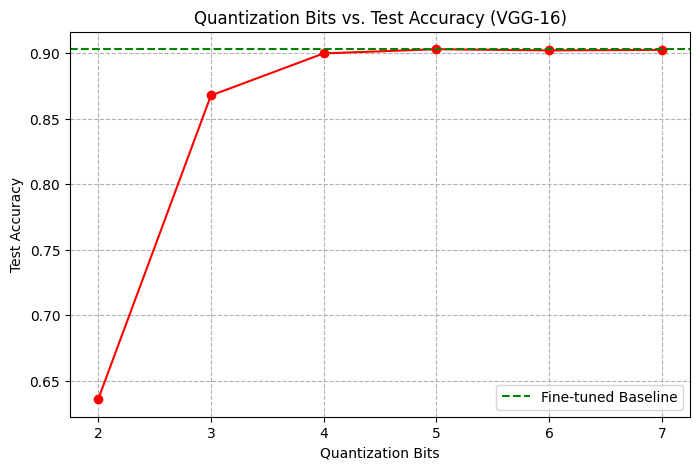

In [ ]:
import matplotlib.pyplot as plt

# Establish baseline
net.load_state_dict(torch.load("net_after_pruning.pt"))
fine_tuned_acc = test(net)

# Bits to test
bit_values = [2, 3, 4, 5, 6, 7]
bit_results = []

print(f"{'Bits':<10} | {'Centroids':<10} | {'Accuracy':<12} | {'Drop from FT (%)':<15}")
print("-" * 55)

for b in bit_values:
    # Always reset to the fine-tuned (pruned) state
    net.load_state_dict(torch.load("net_after_pruning.pt"))

    # Apply quantization
    _ = quantize_whole_model(net, bits=b)

    # Capture accuracy
    current_acc = test(net)

    # Calculate drop relative to the fine-tuned baseline (90.33%)
    drop = (fine_tuned_acc - current_acc) * 100
    bit_results.append((b, current_acc, drop))

    print(f"{b:<10} | {2**b:<10} | {current_acc:<12.4f} | {drop:<15.2f}")

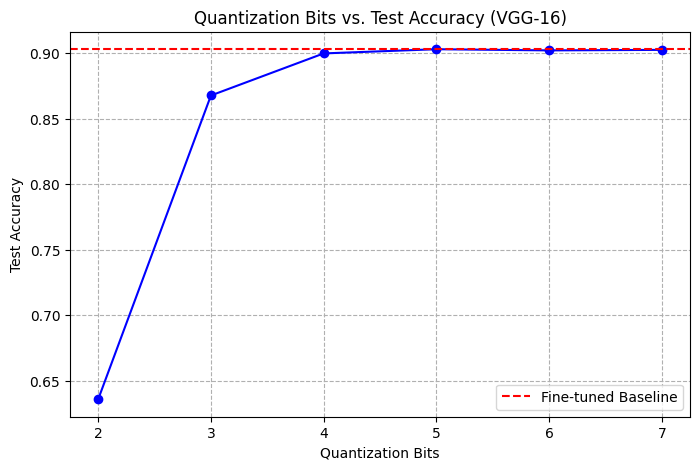

In [ ]:
# Generate the Trade-off Plot
bits, accs, drops = zip(*bit_results)

plt.figure(figsize=(8, 5))
plt.plot(bits, accs, marker='o', linestyle='-', color='blue')
plt.axhline(y=fine_tuned_acc, color='red', linestyle='--', label='Fine-tuned Baseline')
plt.title('Quantization Bits vs. Test Accuracy (VGG-16)')
plt.xlabel('Quantization Bits')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

### Huffman Coding

In [ ]:
frequency_map, encoding_map = huffman_coding(net, centers)
np.save("huffman_encoding", encoding_map)
np.save("huffman_freq", frequency_map)

Original storage for each parameter: 5.0000 bits
Average storage for each parameter after Huffman Coding: 4.5582 bits
Complete 1 layers for Huffman Coding...
Original storage for each parameter: 5.0000 bits
Average storage for each parameter after Huffman Coding: 4.4251 bits
Complete 2 layers for Huffman Coding...
Original storage for each parameter: 5.0000 bits
Average storage for each parameter after Huffman Coding: 4.4777 bits
Complete 3 layers for Huffman Coding...
Original storage for each parameter: 5.0000 bits
Average storage for each parameter after Huffman Coding: 4.6044 bits
Complete 4 layers for Huffman Coding...
Original storage for each parameter: 5.0000 bits
Average storage for each parameter after Huffman Coding: 4.5097 bits
Complete 5 layers for Huffman Coding...
Original storage for each parameter: 5.0000 bits
Average storage for each parameter after Huffman Coding: 4.5333 bits
Complete 6 layers for Huffman Coding...
Original storage for each parameter: 5.0000 bits
Ave